In [ ]:
# #if you didnot install it before run this cell
# !pip install xgboost

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.impute import KNNImputer, SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier

# Model Evaluation & Tuning
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)
from sklearn.inspection import DecisionBoundaryDisplay

In [ ]:
df=pd.read_csv('/content/train.csv')

In [ ]:
df.columns

Index(['id', 'Gender', 'Age', 'Height', 'Weight',
       'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC',
       'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'NObeyesdad'],
      dtype='object')

In [ ]:
df.isnull().sum()

,0
id,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0


In [ ]:
df.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,0,Male,24.443011,1.699998,81.669950,yes,yes,2.000000,2.983297,Sometimes,no,2.763573,no,0.000000,0.976473,Sometimes,Public_Transportation,Overweight_Level_II
1,1,Female,18.000000,1.560000,57.000000,yes,yes,2.000000,3.000000,Frequently,no,2.000000,no,1.000000,1.000000,no,Automobile,Normal_Weight
2,2,Female,18.000000,1.711460,50.165754,yes,yes,1.880534,1.411685,Sometimes,no,1.910378,no,0.866045,1.673584,no,Public_Transportation,Insufficient_Weight
3,3,Female,20.952737,1.710730,131.274851,yes,yes,3.000000,3.000000,Sometimes,no,1.674061,no,1.467863,0.780199,Sometimes,Public_Transportation,Obesity_Type_III
4,4,Male,31.641081,1.914186,93.798055,yes,yes,2.679664,1.971472,Sometimes,no,1.979848,no,1.967973,0.931721,Sometimes,Public_Transportation,Overweight_Level_II


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   Gender                          20758 non-null  object 
 2   Age                             20758 non-null  float64
 3   Height                          20758 non-null  float64
 4   Weight                          20758 non-null  float64
 5   family_history_with_overweight  20758 non-null  object 
 6   FAVC                            20758 non-null  object 
 7   FCVC                            20758 non-null  float64
 8   NCP                             20758 non-null  float64
 9   CAEC                            20758 non-null  object 
 10  SMOKE                           20758 non-null  object 
 11  CH2O                            20758 non-null  float64
 12  SCC                             

Split The Data


In [ ]:
X=df.drop('NObeyesdad',axis=1)
y=df['NObeyesdad']

In [ ]:
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=41234)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=1234)

# The Attributes:
## Of Eating Habits:
* Frequent consumption of high caloric food (FAVC).
* Frequency of consumption of vegetables (FCVC).
* Number of main meals (NCP).
* Consumption of food between meals (CAEC).
* Consumption of water daily (CH20).
* Consumption of alcohol (CALC).

##Of Physical Condition:
* Calories consumption monitoring (SCC).
* Physical activity frequency (FAF).
* Time using technology devices (TUE).
* Transportation used (MTRANS).



In [ ]:
X_train.head()

,id,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS
9900,9900,Female,16.306870,1.600000,65.062945,yes,yes,2.753752,3.0,Sometimes,no,2.452986,yes,0.428173,0.128895,Sometimes,Public_Transportation
14297,14297,Male,21.084625,1.716289,80.000000,yes,yes,2.000000,3.0,Sometimes,no,2.000000,no,0.000000,1.343044,Sometimes,Public_Transportation
13800,13800,Male,18.000000,1.700000,70.000000,no,yes,3.000000,3.0,Sometimes,no,2.000000,yes,1.000000,2.000000,Sometimes,Public_Transportation
15030,15030,Male,18.000000,1.700038,84.729197,yes,yes,2.535315,3.0,Sometimes,no,1.753464,no,1.000000,0.460866,Sometimes,Public_Transportation
8822,8822,Male,21.106056,1.704573,80.000000,yes,yes,2.000000,1.0,Sometimes,no,1.606076,no,2.834373,1.556052,no,Public_Transportation


In [ ]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12454 entries, 9900 to 14975
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              12454 non-null  int64  
 1   Gender                          12454 non-null  object 
 2   Age                             12454 non-null  float64
 3   Height                          12454 non-null  float64
 4   Weight                          12454 non-null  float64
 5   family_history_with_overweight  12454 non-null  object 
 6   FAVC                            12454 non-null  object 
 7   FCVC                            12454 non-null  float64
 8   NCP                             12454 non-null  float64
 9   CAEC                            12454 non-null  object 
 10  SMOKE                           12454 non-null  object 
 11  CH2O                            12454 non-null  float64
 12  SCC                             12

#Descriptive Statistics.


In [ ]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12454.0,10318.608238,5981.200299,1.00,5183.250000,10232.500000,15456.750000,20756.000000
Age,12454.0,23.831354,5.685114,14.00,20.000000,22.830929,26.000000,61.000000
Height,12454.0,1.700527,0.086710,1.45,1.632377,1.700000,1.761068,1.975663
Weight,12454.0,88.096248,26.360958,39.00,66.650927,84.622675,111.720238,165.057269
FCVC,12454.0,2.446972,0.534135,1.00,2.000000,2.424134,3.000000,3.000000
NCP,12454.0,2.764040,0.705864,1.00,3.000000,3.000000,3.000000,4.000000
CH2O,12454.0,2.030821,0.604905,1.00,1.808478,2.000000,2.531852,3.000000
FAF,12454.0,0.981768,0.834668,0.00,0.008368,1.000000,1.583832,3.000000
TUE,12454.0,0.616739,0.602009,0.00,0.000000,0.573887,1.000000,2.000000


##Demographic Data
* **Age:**

    Mean: 23.81 years.

    Standard Deviation: 5.65.

    Minimum Age: 14 years.

    Maximum Age: 61 years.

    25% of the population is below 20 years old.

    75% is below 26 years old.

* **Height(m):**

    Mean: 1.70 m.

    Standard Deviation: 0.087.
    Minimum Height: 1.45 m.

    Maximum Height: 1.98 m.

    Most individuals are between 1.63 m and 1.76 m.
* **Weight (kg):**

    Mean: 87.81 kg.

    Standard Deviation: 26.36 kg.

    Minimum Weight: 39 kg.

    Maximum Weight: 165.06 kg.

    75th percentile is 111.6 kg.--> indicating a high proportion of individuals with overweight or obesity.

##Habits Of Eat.
* **Frequency of Vegetable Consumption (FCVC):** (Scale: 1-3)

    Mean: 2.44.

    Standard Deviation: 0.53.
   
    75th percentile = 3.00.

    *Most individuals have a moderate to high vegetable consumption.*

* **Number of Main Meals per Day (NCP)** (Scale: 1-4)

    Mean: 2.76 meals/day.

    Standard Deviation: 0.71.

    50% of the population eats 3 meals daily, with some individuals consuming only one meal per day (min) or up to four meals per day (max).

* **Daily Water Consumption (CH2O):** (Scale: 1-3)

    Mean: 2.03.

    Standard Deviation: 0.61.

    25% of individuals consume less than 1.8 liters of water per day, while the majority consume 2+ liters.


##Physical Activity & Techonology usage.
* **physical Activity Frequency (FAF):** (Scale: 0-3)

    Mean: 0.98.

    Standard Deviation: 0.84.

    Half of the population has low physical activity levels ,with some individuals having zero physical activity.

* **Time Spent Using Technology (TUE):** (Scale: 0-2)

    Mean: 0.61.

    Standard Deviation: 0.60.
    
    50% of individuals spend around 0.57 hours daily on devices, while some spend up to 2 hours per day.

# EDA


## Univariant Analysis.

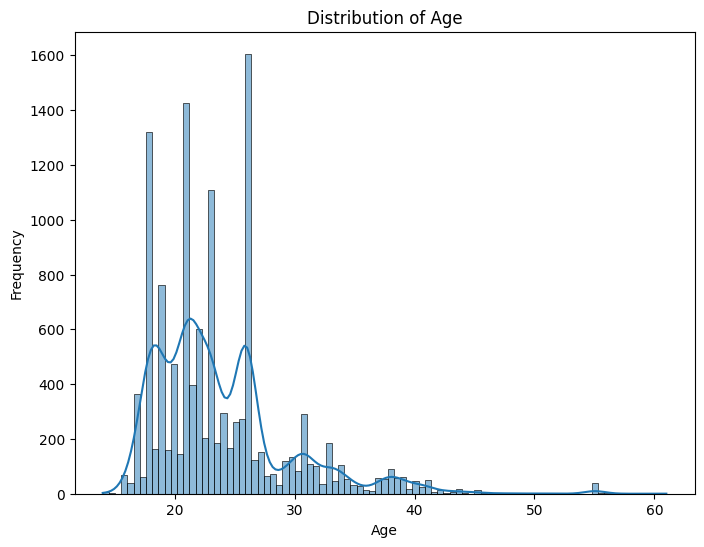

In [ ]:
# Distribution of 'Age'
plt.figure(figsize=(8, 6))
sns.histplot(X_train['Age'], kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()



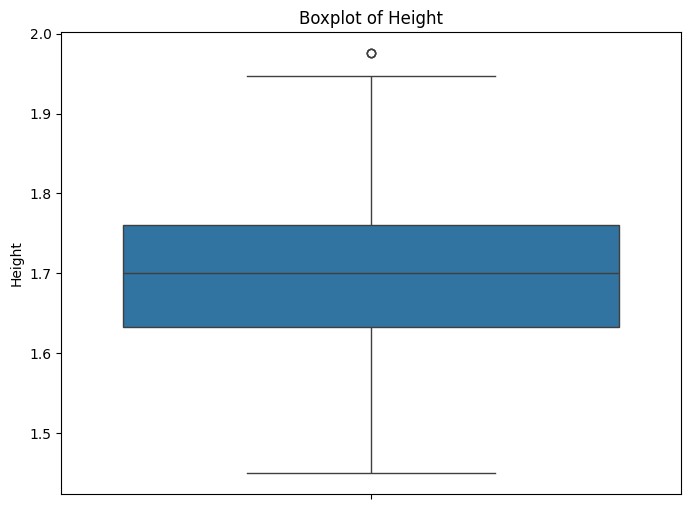

In [ ]:
# Boxplot of 'Height'
plt.figure(figsize=(8, 6))
sns.boxplot(y=X_train['Height'])
plt.title('Boxplot of Height')
plt.ylabel('Height')
plt.show()


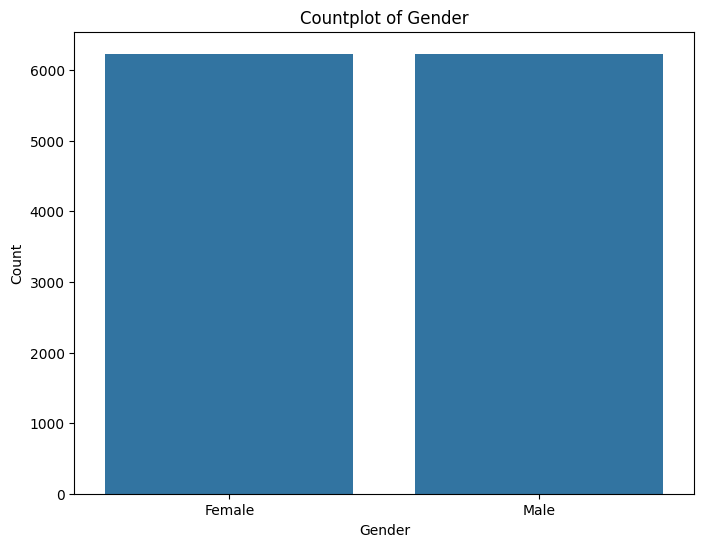

In [ ]:
# Countplot of 'Gender'
plt.figure(figsize=(8, 6))
sns.countplot(x='Gender', data=X_train)
plt.title('Countplot of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

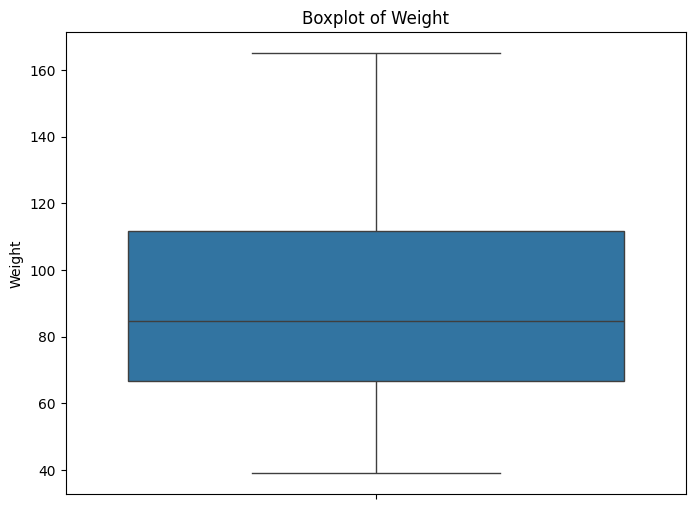

In [ ]:
# Boxplot of 'Weight'
plt.figure(figsize=(8,6))
sns.boxplot(y=X_train['Weight'])
plt.title('Boxplot of Weight')
plt.ylabel('Weight')
plt.show()


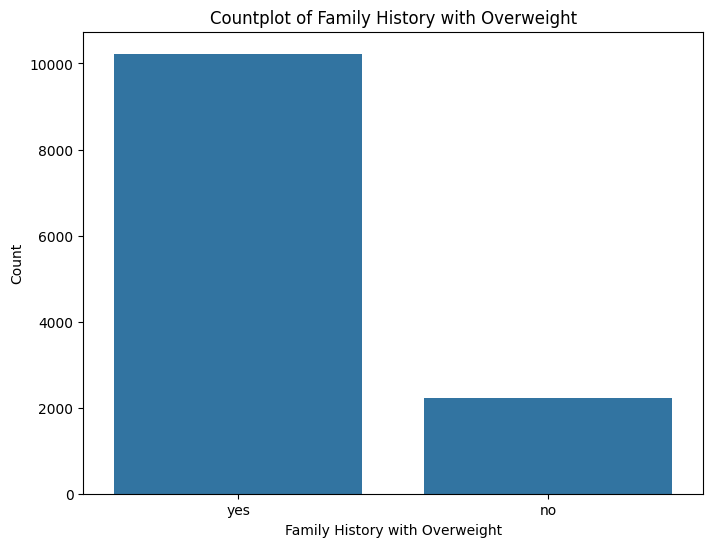

In [ ]:
# Countplot of 'family_history_with_overweight'
plt.figure(figsize=(8,6))
sns.countplot(x='family_history_with_overweight', data=X_train)
plt.title('Countplot of Family History with Overweight')
plt.xlabel('Family History with Overweight')
plt.ylabel('Count')
plt.show()

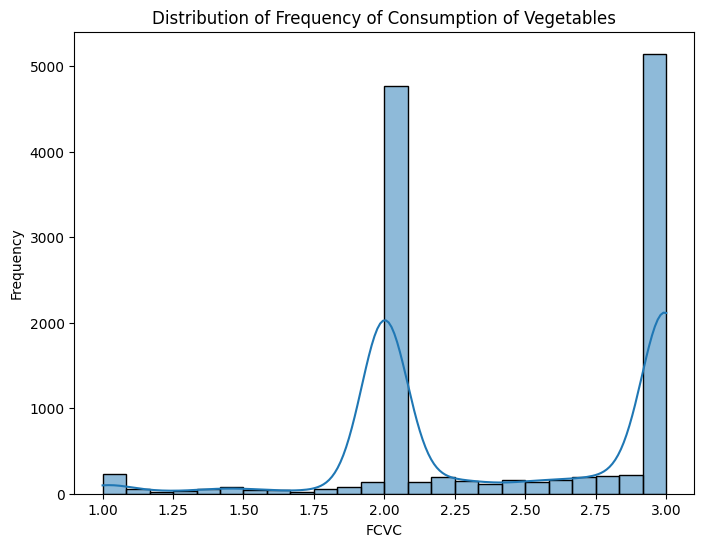

In [ ]:
# Distribution of 'FCVC'
plt.figure(figsize=(8,6))
sns.histplot(X_train['FCVC'], kde=True)
plt.title('Distribution of Frequency of Consumption of Vegetables')
plt.xlabel('FCVC')
plt.ylabel('Frequency')
plt.show()

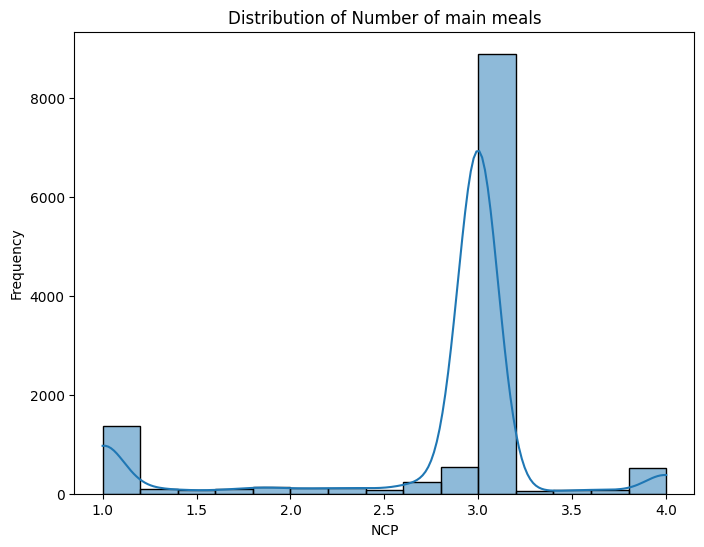

In [ ]:
# Distribution of 'NCP'
plt.figure(figsize=(8,6))
sns.histplot(X_train['NCP'], kde=True)
plt.title('Distribution of Number of main meals')
plt.xlabel('NCP')
plt.ylabel('Frequency')
plt.show()

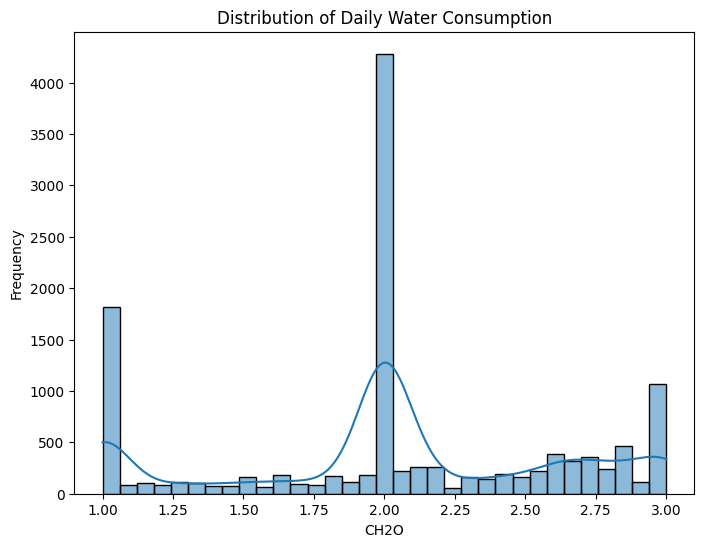

In [ ]:
# Distribution of 'CH2O'
plt.figure(figsize=(8,6))
sns.histplot(X_train['CH2O'], kde=True)
plt.title('Distribution of Daily Water Consumption')
plt.xlabel('CH2O')
plt.ylabel('Frequency')
plt.show()

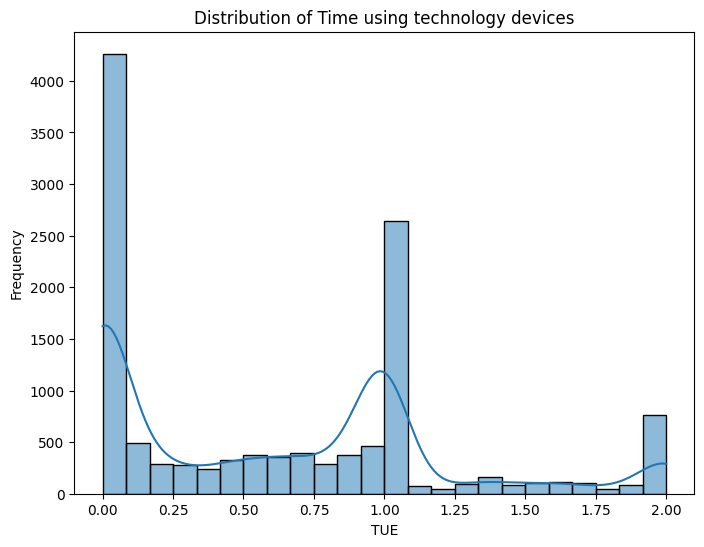

In [ ]:
# Distribution of 'TUE'
plt.figure(figsize=(8,6))
sns.histplot(X_train['TUE'], kde=True)
plt.title('Distribution of Time using technology devices')
plt.xlabel('TUE')
plt.ylabel('Frequency')
plt.show()


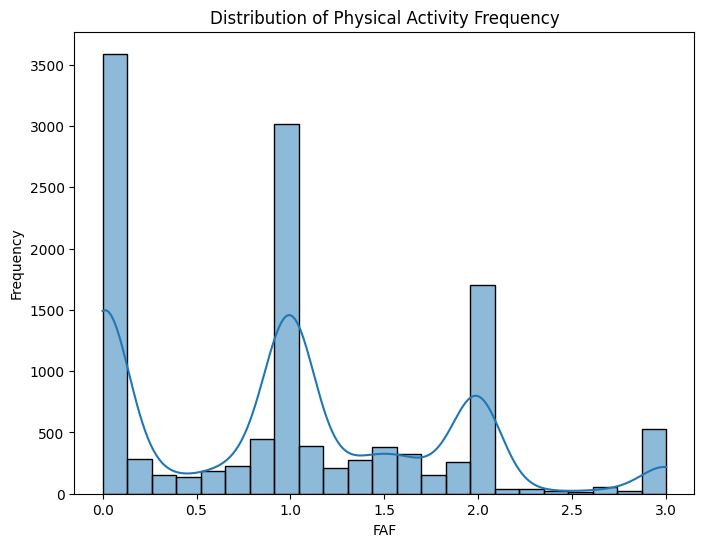

In [ ]:
# Distribution of 'FAF'
plt.figure(figsize=(8,6))
sns.histplot(X_train['FAF'], kde=True)
plt.title('Distribution of Physical Activity Frequency')
plt.xlabel('FAF')
plt.ylabel('Frequency')
plt.show()


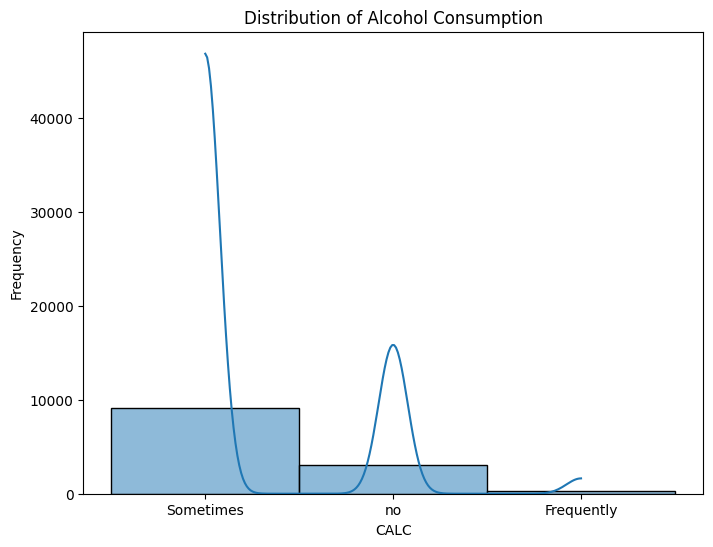

In [ ]:
# Distribution of 'CALC'
plt.figure(figsize=(8,6))
sns.histplot(X_train['CALC'], kde=True)
plt.title('Distribution of Alcohol Consumption')
plt.xlabel('CALC')
plt.ylabel('Frequency')
plt.show()


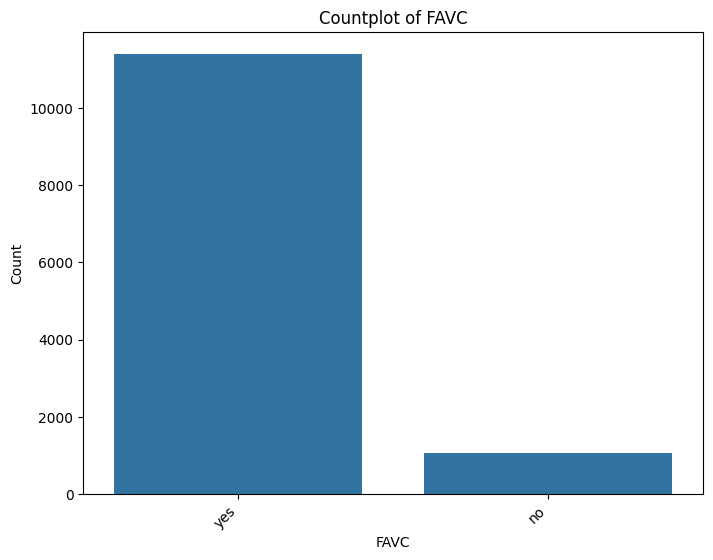

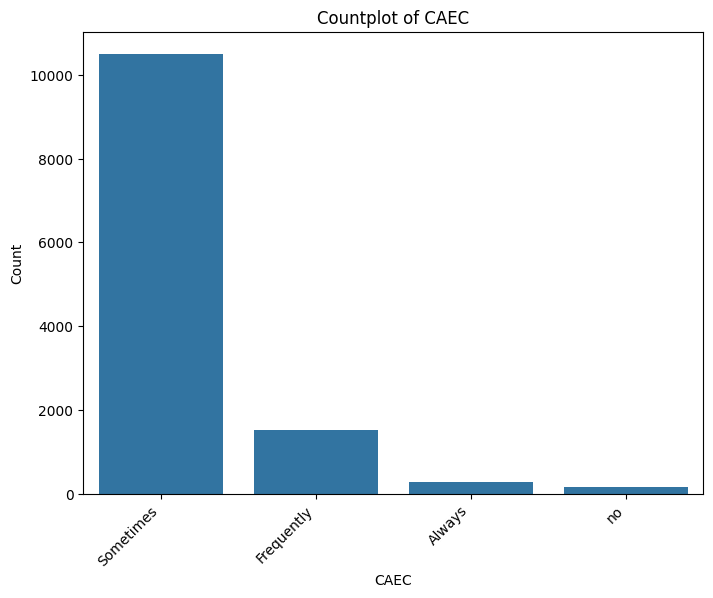

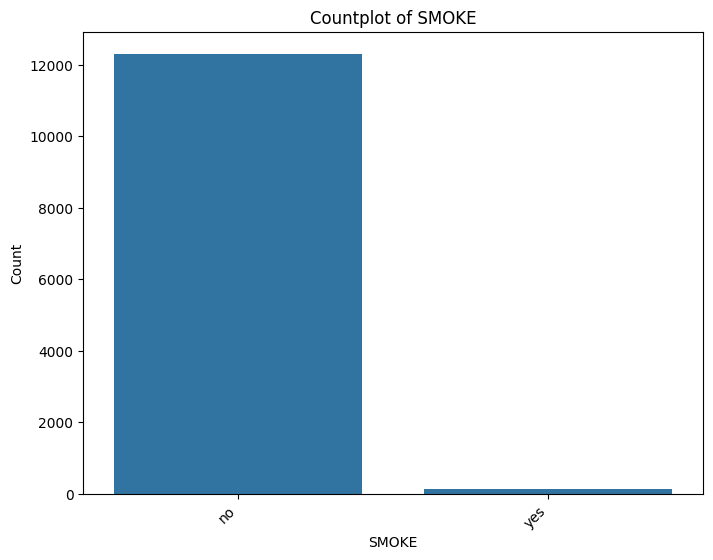

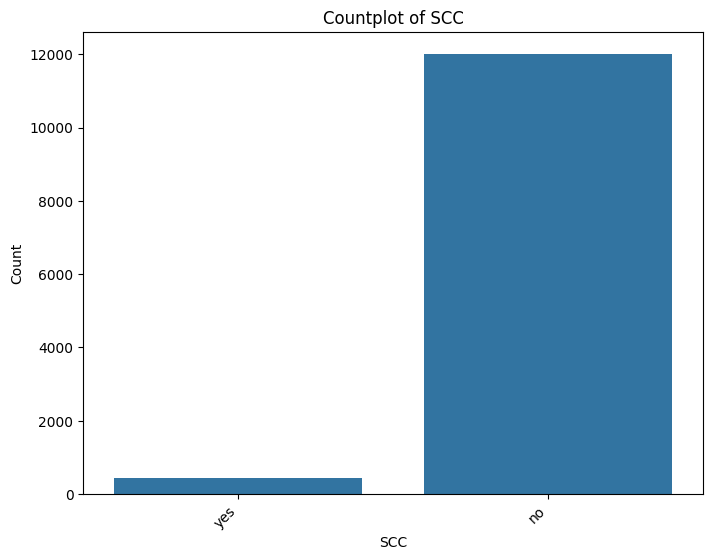

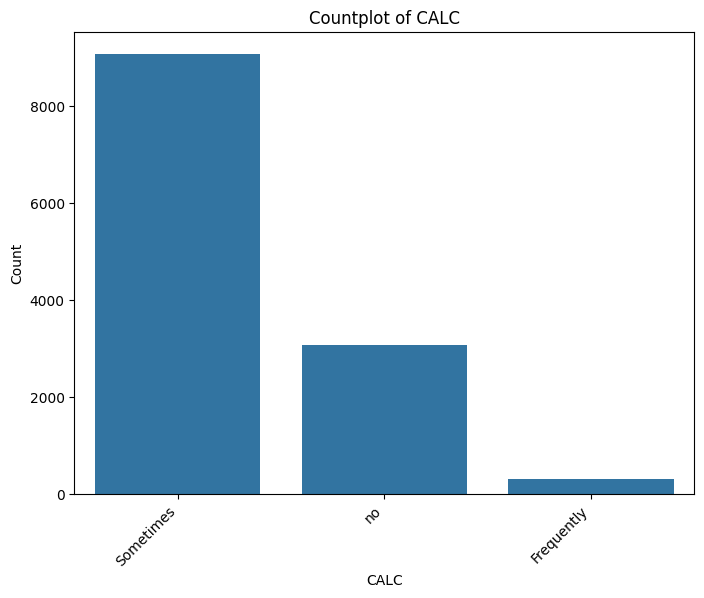

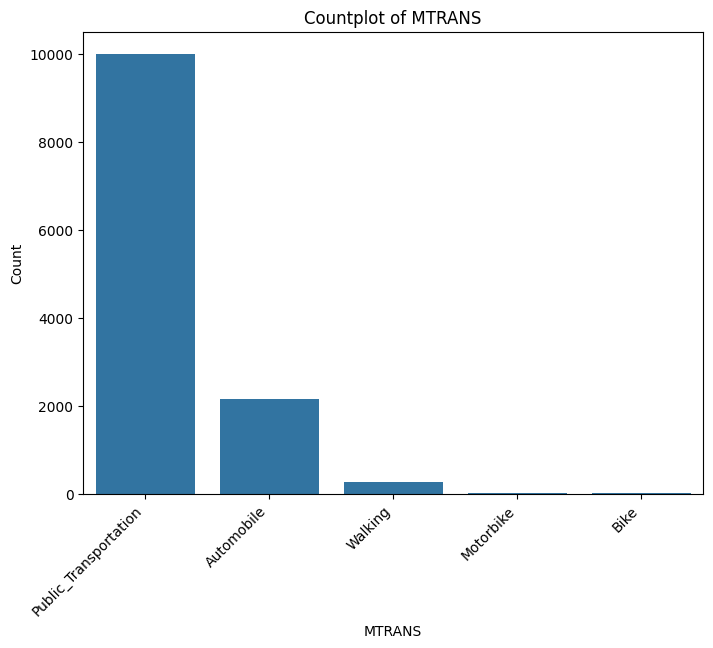

In [ ]:
for col in ['FAVC', 'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS']:
  plt.figure(figsize=(8, 6))
  sns.countplot(x=col, data=X_train)
  plt.title(f'Countplot of {col}')
  plt.xlabel(col)
  plt.ylabel('Count')
  plt.xticks(rotation=45, ha='right')
  plt.show()

In [ ]:
X_train.duplicated().sum()

np.int64(0)

In [ ]:
X_train=X_train.drop(['id','SCC','SMOKE'], axis=1)

In [ ]:
num_col=X_train.select_dtypes(include=['number'])
num_col.columns

Index(['Age', 'Height', 'Weight', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'], dtype='object')

In [ ]:
sc=StandardScaler()
X_train[num_col.columns]=sc.fit_transform(X_train[num_col.columns])
X_test[num_col.columns]=sc.transform(X_test[num_col.columns])
X_val[num_col.columns]=sc.transform(X_val[num_col.columns])

Preprocessing on train data

In [ ]:
cat_cols=X_train.select_dtypes(include=['object'])
cat_cols.columns

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'CALC',
       'MTRANS'],
      dtype='object')

In [ ]:
for col in (X_train.select_dtypes(include=['object']).columns):
   print(col,':',X_train[col].unique())

Gender : ['Female' 'Male']
family_history_with_overweight : ['yes' 'no']
FAVC : ['yes' 'no']
CAEC : ['Sometimes' 'Frequently' 'Always' 'no']
CALC : ['Sometimes' 'no' 'Frequently']
MTRANS : ['Public_Transportation' 'Automobile' 'Walking' 'Motorbike' 'Bike']


In [ ]:
X_train['NCP'] = X_train['NCP'].round()
X_train['FAF'] = X_train['FAF'].round()

In [ ]:
binary_col= ['family_history_with_overweight', 'FAVC','Gender']
for col in binary_col:
    encoder = LabelEncoder()
    X_train[col] = encoder.fit_transform(X_train[col])
    X_test[col] = encoder.transform(X_test[col])
    X_val[col] = encoder.transform(X_val[col])

In [ ]:
ordinal_features = ['CAEC', 'CALC']
categories = [
    ['no', 'Sometimes', 'Frequently', 'Always'],
    ['no', 'Sometimes', 'Frequently']
]
encoder_ord = OrdinalEncoder(categories=categories)
X_train[ordinal_features] = encoder_ord.fit_transform(X_train[ordinal_features])
X_train[ordinal_features] = X_train[ordinal_features].astype(int)

In [ ]:
columns_to_encode = ['Gender', 'family_history_with_overweight', 'FAVC', 'MTRANS']

encoder = OneHotEncoder(drop="first", sparse_output=False)

x_train_onehot = encoder.fit_transform(X_train[columns_to_encode])
onehot_columns = encoder.get_feature_names_out(columns_to_encode)

onehot_df = pd.DataFrame(x_train_onehot, columns= onehot_columns, index=X_train.index)

X_train = X_train.drop(columns=columns_to_encode)

X_train = pd.concat([X_train, onehot_df], axis=1)


In [ ]:
encoder_label = LabelEncoder()
y_train = encoder_label.fit_transform(y_train)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

Preprocessing on Valdiation data

In [ ]:
X_val = X_val.drop(["id","SMOKE","SCC"],axis=1)

In [ ]:
X_val['NCP'] = X_val['NCP'].round()
X_val['FAF'] = X_val['FAF'].round()

In [ ]:
ordinal_features = ['CAEC', 'CALC']
categories = [
    ['no', 'Sometimes', 'Frequently', 'Always'],
    ['no', 'Sometimes', 'Frequently']
]
X_val[ordinal_features] = encoder_ord.transform(X_val[ordinal_features])
X_val[ordinal_features] = X_val[ordinal_features].astype(int)


In [ ]:
columns_to_encode = ['Gender', 'family_history_with_overweight', 'FAVC', 'MTRANS']

X_val_onehot = encoder.transform(X_val[columns_to_encode])
onehot_columns = encoder.get_feature_names_out(columns_to_encode)

onehot_df = pd.DataFrame(X_val_onehot, columns= onehot_columns, index=X_val.index)

X_val = X_val.drop(columns=columns_to_encode)

X_val = pd.concat([X_val, onehot_df], axis=1)


In [ ]:
encoder_label = LabelEncoder()
y_val = encoder_label.fit_transform(y_val)

In [ ]:
X_val = scaler.transform(X_val)

# **Modeling**


**Logistic Regression**

In [ ]:
clf = LogisticRegression(max_iter=10000, random_state=0)
clf.fit(X_train, y_train)
y_pred=clf.predict(X_val)
acc = accuracy_score(y_val,y_pred ) * 100
print("Accuracy on valdation=",acc)

Accuracy on valdation= 85.40462427745665


**Support Vector Machine**

In [ ]:
svm = SVC(kernel="rbf", gamma=0.5, C=1.0)
svm.fit(X_train,y_train)
y_pred = svm.predict(X_val)
score=svm.score(X_train, y_train)
print("Training score: ",score)

score=svm.score(X_val, y_val)
print("Valdiation: ",score)

print(classification_report(y_pred, y_val))

Training score:  0.9479685241689417
Valdiation:  0.7642100192678227
              precision    recall  f1-score   support

           0       0.66      0.90      0.76       383
           1       0.80      0.48      0.60       998
           2       0.74      0.82      0.78       528
           3       0.90      0.96      0.93       614
           4       1.00      1.00      1.00       815
           5       0.46      0.60      0.52       375
           6       0.59      0.66      0.62       439

    accuracy                           0.76      4152
   macro avg       0.74      0.77      0.74      4152
weighted avg       0.78      0.76      0.76      4152



**Decision Tree**

In [ ]:
DT = DecisionTreeClassifier(max_depth = 9, random_state=42)
DT.fit(X_train, y_train)
y_pred=DT.predict(X_val)
score=DT.score(X_train, y_train)
print("Accuracy onTrain: ",score)

accuracy = accuracy_score(y_val, y_pred)
print("Accuracy on Valdation:",accuracy)

Accuracy onTrain:  0.9110325999678818
Accuracy on Valdation: 0.8728323699421965


**Random Forest**

In [ ]:
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy on Valdation: {accuracy * 100:.2f}%')

Accuracy on Valdation: 89.43%


**GradientBoosting**

In [ ]:
gb = GradientBoostingClassifier(n_estimators = 150)
gb.fit(X_train, y_train)
y_pred = gb.predict(X_val)
score=gb.score(X_train, y_train)
print("Training score: ",score)

report=classification_report(y_val, y_pred)
print("\nClassification Report:")
print(report)


Training score:  0.9342379958246346

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       522
           1       0.85      0.88      0.86       598
           2       0.91      0.88      0.89       589
           3       0.96      0.96      0.96       651
           4       1.00      1.00      1.00       814
           5       0.80      0.76      0.78       483
           6       0.78      0.82      0.80       495

    accuracy                           0.90      4152
   macro avg       0.89      0.89      0.89      4152
weighted avg       0.90      0.90      0.90      4152



**XGBosot**

In [ ]:
xgb = XGBClassifier(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_val)
accuracy = accuracy_score(y_val, y_pred)
print(f'Accuracy on Valdation: {accuracy * 100:.2f}%')

Accuracy on Valdation: 90.22%


**Generalization**

In [ ]:
params = {'n_estimators': [100, 200, 300],
         'learning_rate': [0.1, 0.01, 0.001],
         'max_depth': [3, 6, 9]}

score = 'accuracy'

In [ ]:
model_xgb = GridSearchCV(xgb, params, scoring = score, n_jobs = -1)
model_xgb.fit(X_train, y_train)
print(model_xgb.best_params_)
print(model_xgb.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300}
0.9023608847271867
